> **Cell 1 — Setup & Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
np.random.seed(42)
 
df = sns.load_dataset('titanic')
 
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (891, 15)


> **CELL 2 — Q1(a): First 8 and Last 5 Rows**

In [2]:
print("=" * 60)
print("FIRST 8 ROWS")
print("=" * 60)
display(df.head(8))
 
print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
display(df.tail(5))

FIRST 8 ROWS


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False



LAST 5 ROWS


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


> **CELL 3 — Q1(b): Shape, dtypes, describe() for numeric & categorical**

In [3]:
print("Shape:", df.shape)
print("\n--- Data Types ---")
print(df.dtypes)
 
print("\n--- Statistical Summary: Numeric Columns ---")
display(df.describe())
 
print("\n--- Statistical Summary: Categorical Columns ---")
display(df.describe(include=['object', 'category', 'bool']))

Shape: (891, 15)

--- Data Types ---
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

--- Statistical Summary: Numeric Columns ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Statistical Summary: Categorical Columns ---


,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


> **CELL 4 — Q1(c): Missing Values Analysis**

In [6]:
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df)) * 100
 
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct.round(2)
})
missing_df = missing_df[missing_df['Missing Count'] > 0]
 
# Logical reasons for missingness
reasons = {
    'age':         'Age was not always recorded, especially for lower-class passengers; some boarded under aliases.',
    'embarked':    'Only 2 rows missing; likely a data entry omission for these specific passengers.',
    'deck':        'Cabin/deck info was mostly not recorded for 3rd-class passengers; not required for their tickets.',
    'embark_town': 'Same 2 rows as embarked — the port name is derived from the embarked code.'
}
missing_df['Likely Reason'] = missing_df.index.map(reasons)
 
print("=" * 60)
print("COLUMNS WITH MISSING VALUES")
print("=" * 60)
display(missing_df)

COLUMNS WITH MISSING VALUES


,Missing Count,Missing %,Likely Reason
age,177,19.87,"Age was not always recorded, especially for lo..."
embarked,2,0.22,Only 2 rows missing; likely a data entry omiss...
deck,688,77.22,Cabin/deck info was mostly not recorded for 3r...
embark_town,2,0.22,Same 2 rows as embarked — the port name is der...


> **CELL 5 — Q1(d): Overall & Per-Class Survival Rate**

In [7]:
overall_survival = df['survived'].mean()
 
class_survival = df.groupby('pclass')['survived'].mean().reset_index()
class_survival.columns = ['Passenger Class', 'Survival Rate']
class_survival['Survival Rate'] = class_survival['Survival Rate'].round(4)
 
overall_row = pd.DataFrame({'Passenger Class': ['Overall'], 'Survival Rate': [round(overall_survival, 4)]})
survival_summary = pd.concat([overall_row, class_survival], ignore_index=True)
 
print("=" * 60)
print("SURVIVAL RATE SUMMARY")
print("=" * 60)
display(survival_summary)

SURVIVAL RATE SUMMARY


,Passenger Class,Survival Rate
0,Overall,0.3838
1,1,0.6296
2,2,0.4728
3,3,0.2424


> **CELL 6 — Q2(a): Impute Missing Age Values**

In [8]:
"""
STRATEGY: Group-based median imputation using sex + pclass.
WHY: Age varies significantly by passenger class and sex.
     For example, 1st-class male passengers tend to be older than
     3rd-class female passengers. Using group medians preserves
     this heterogeneity better than a single global median.
LIMITATION: It assumes within-group age distributions are similar
            to observed passengers, which may not hold for passengers
            whose age is missing for non-random reasons.
"""
 
# Show group medians before imputation
group_medians = df.groupby(['sex', 'pclass'])['age'].median()
print("Group Medians (sex + pclass):")
print(group_medians)
 
# Apply group-based median imputation
df['age'] = df.groupby(['sex', 'pclass'])['age'].transform(
    lambda x: x.fillna(x.median())
)
 
print(f"\nMissing 'age' values remaining: {df['age'].isnull().sum()}")

Group Medians (sex + pclass):
sex     pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: age, dtype: float64

Missing 'age' values remaining: 0


> **CELL 7 — Q2(b): Drop 'deck' Column**

In [9]:
"""
JUSTIFICATION FOR DROPPING 'deck':
The 'deck' column has ~77% missing values. Imputing a column with
this level of missingness would be highly speculative — any imputed
values would dominate the data and introduce significant bias.
Unlike 'age', there is no reliable proxy variable from which to
infer deck. Dropping it is the more honest analytical choice.
"""
 
df.drop(columns=['deck'], inplace=True)
print("'deck' column dropped.")
print(f"Remaining columns: {list(df.columns)}")

'deck' column dropped.
Remaining columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


> **CELL 8 — Q2(c): Handle Missing 'embarked' Using Mode**

In [10]:
mode_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(mode_embarked, inplace=True)
 
# Also fix embark_town
mode_town = df['embark_town'].mode()[0]
df['embark_town'].fillna(mode_town, inplace=True)
 
print(f"Mode used for 'embarked': {mode_embarked}")
print(f"Null values in 'embarked': {df['embarked'].isnull().sum()}")
print(f"Null values in 'embark_town': {df['embark_town'].isnull().sum()}")

Mode used for 'embarked': S
Null values in 'embarked': 0
Null values in 'embark_town': 0


> **CELL 9 — Q2(d): Create 'family_size' and 'travel_group'**

In [11]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
 
def categorize_travel(size):
    if size == 1:
        return 'Solo'
    elif 2 <= size <= 4:
        return 'Small'
    else:
        return 'Large'
 
df['travel_group'] = df['family_size'].apply(categorize_travel)
 
print("Value counts for 'travel_group':")
print(df['travel_group'].value_counts())

Value counts for 'travel_group':
travel_group
Solo     537
Small    292
Large     62
Name: count, dtype: int64


> **CELL 10 — Q2(e): Create 'age_group' Column**

In [12]:
bins   = [0, 12, 17, 59, 120]
labels = ['Child', 'Teen', 'Adult', 'Senior']
 
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)
 
# Verify no NaN bins
print(f"NaN in age_group: {df['age_group'].isnull().sum()}")
print("\nValue counts for 'age_group':")
print(df['age_group'].value_counts())

NaN in age_group: 0

Value counts for 'age_group':
age_group
Adult     752
Child      69
Teen       44
Senior     26
Name: count, dtype: int64


> **CELL 11 — Q2(f): Final Null-Check**

In [13]:
columns_in_use = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
                  'fare', 'embarked', 'class', 'who', 'embark_town',
                  'alone', 'family_size', 'travel_group', 'age_group']
 
null_check = df[columns_in_use].isnull().sum().reset_index()
null_check.columns = ['Column', 'Null Count']
 
print("=" * 40)
print("FINAL NULL-CHECK SUMMARY")
print("=" * 40)
display(null_check)
print(f"\nTotal nulls across used columns: {df[columns_in_use].isnull().sum().sum()}")

FINAL NULL-CHECK SUMMARY


,Column,Null Count
0,survived,0
1,pclass,0
2,sex,0
3,age,0
4,sibsp,0
5,parch,0
6,fare,0
7,embarked,0
8,class,0
9,who,0



Total nulls across used columns: 0


> **CELL 12 — Q3(a): Age Histogram — 3 Bin Sizes Side-by-Side**

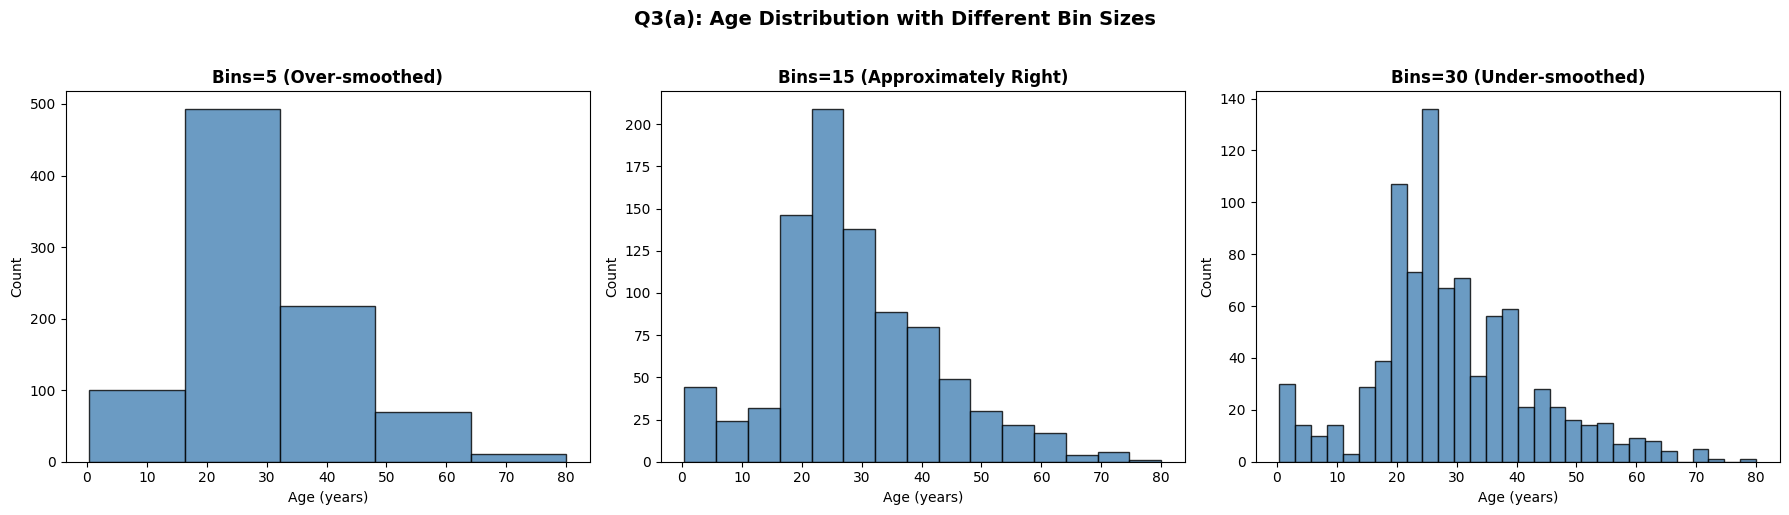

'\nINTERPRETATION:\n- Bins=5  → Too few bars, hides natural variation and peaks. Over-smoothed.\n- Bins=15 → Reveals the overall shape clearly — a right-skewed distribution\n             with peaks in young adults (~20-30) and a smaller bump in children.\n             This is the best choice.\n- Bins=30 → Too many bars, creates a jagged and noisy appearance that makes it\n             hard to see the underlying shape. Under-smoothed.\nBEST BIN SIZE: 15 — it balances granularity and clarity.\n'

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
bin_sizes = [5, 15, 30]
titles = [
    'Bins=5 (Over-smoothed)',
    'Bins=15 (Approximately Right)',
    'Bins=30 (Under-smoothed)'
]
 
for ax, bins_val, title in zip(axes, bin_sizes, titles):
    ax.hist(df['age'], bins=bins_val, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Age (years)')
    ax.set_ylabel('Count')
 
plt.suptitle('Q3(a): Age Distribution with Different Bin Sizes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

"""
INTERPRETATION:
- Bins=5  → Too few bars, hides natural variation and peaks. Over-smoothed.
- Bins=15 → Reveals the overall shape clearly — a right-skewed distribution
             with peaks in young adults (~20-30) and a smaller bump in children.
             This is the best choice.
- Bins=30 → Too many bars, creates a jagged and noisy appearance that makes it
             hard to see the underlying shape. Under-smoothed.
BEST BIN SIZE: 15 — it balances granularity and clarity.
"""

> **CELL 13 — Q3(b): Best-Bin Histogram with KDE Overlay**

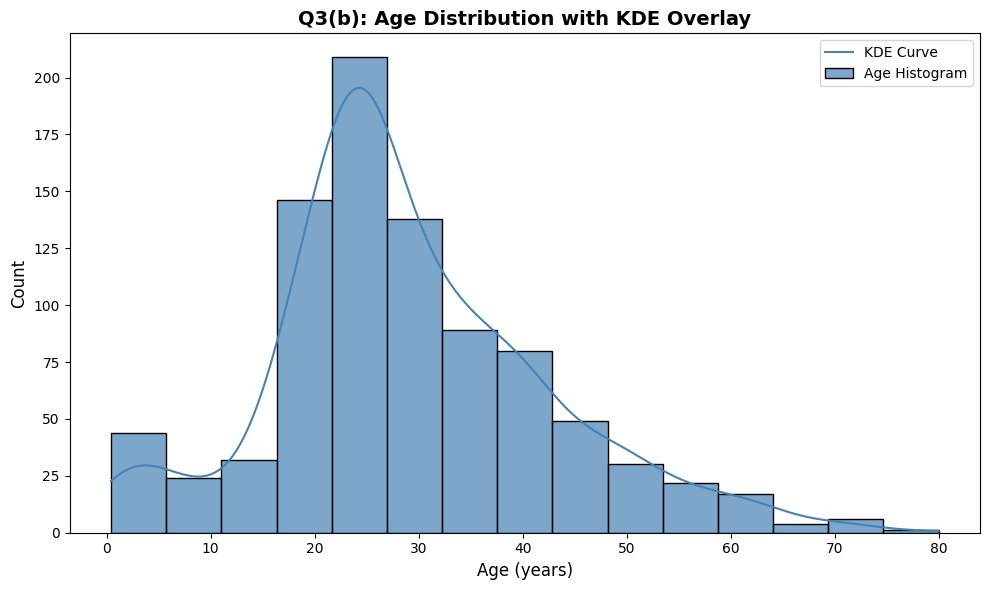

'\nINTERPRETATION:\nThe distribution is right-skewed with the bulk of passengers concentrated\nbetween ages 20 and 40. There is a noticeable secondary peak around ages 0-5,\nindicating a significant number of young children aboard, likely families.\nThe long right tail represents older passengers, but they were relatively rare.\nThis bimodal tendency (young adults + young children) reflects the social\ncomposition of a 1912 transatlantic voyage — primarily working-age emigrants\nand some families with young children in 3rd class.\n'

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
 
sns.histplot(df['age'], bins=15, kde=True, color='steelblue',
             edgecolor='black', alpha=0.7, ax=ax)
 
ax.set_title('Q3(b): Age Distribution with KDE Overlay', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.legend(['KDE Curve', 'Age Histogram'], loc='upper right')
 
plt.tight_layout()
plt.show()


"""
INTERPRETATION:
The distribution is right-skewed with the bulk of passengers concentrated
between ages 20 and 40. There is a noticeable secondary peak around ages 0-5,
indicating a significant number of young children aboard, likely families.
The long right tail represents older passengers, but they were relatively rare.
This bimodal tendency (young adults + young children) reflects the social
composition of a 1912 transatlantic voyage — primarily working-age emigrants
and some families with young children in 3rd class.
"""

> **CELL 14 — Q3(c): KDE — Survivors vs Non-Survivors**

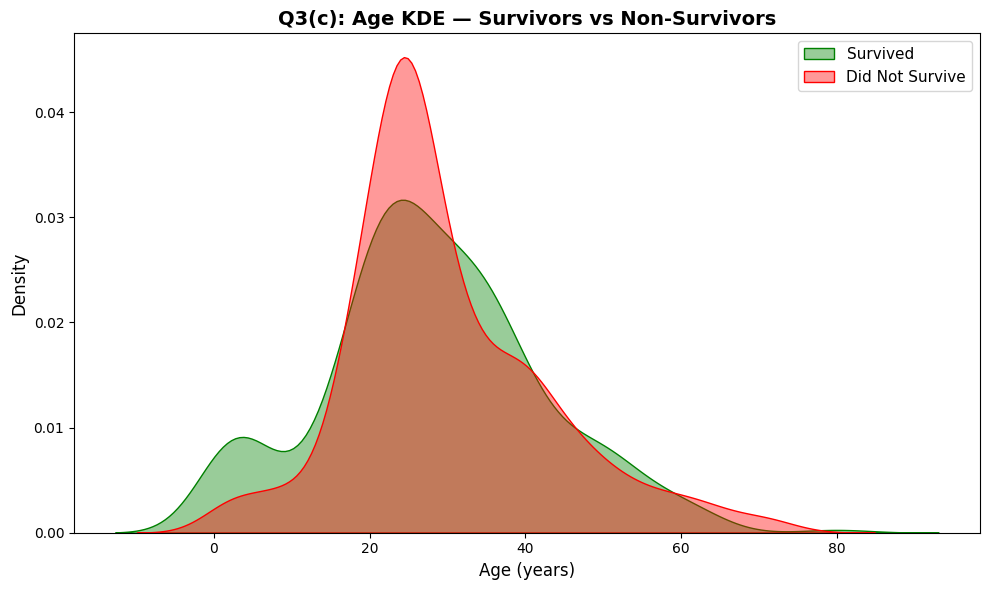

'\nINTERPRETATION:\n- Ages 0–10 (Children): The survivor KDE is notably higher than non-survivor KDE,\n  suggesting children were prioritised during evacuation ("women and children first").\n- Ages 18–35 (Young Adults): Non-survivors dominate this range — many were male\n  passengers who were not given priority for lifeboats.\n- The distributions begin to converge at older ages (60+), suggesting elderly\n  passengers had mixed survival outcomes regardless of the rescue priority.\n'

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
 
sns.kdeplot(df[df['survived'] == 1]['age'], ax=ax, label='Survived', color='green', fill=True, alpha=0.4)
sns.kdeplot(df[df['survived'] == 0]['age'], ax=ax, label='Did Not Survive', color='red', fill=True, alpha=0.4)
 
ax.set_title('Q3(c): Age KDE — Survivors vs Non-Survivors', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=11)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
- Ages 0–10 (Children): The survivor KDE is notably higher than non-survivor KDE,
  suggesting children were prioritised during evacuation ("women and children first").
- Ages 18–35 (Young Adults): Non-survivors dominate this range — many were male
  passengers who were not given priority for lifeboats.
- The distributions begin to converge at older ages (60+), suggesting elderly
  passengers had mixed survival outcomes regardless of the rescue priority.
"""

> **CELL 15 — Q4(a): Fare Distribution — Raw & Log-Transforme**

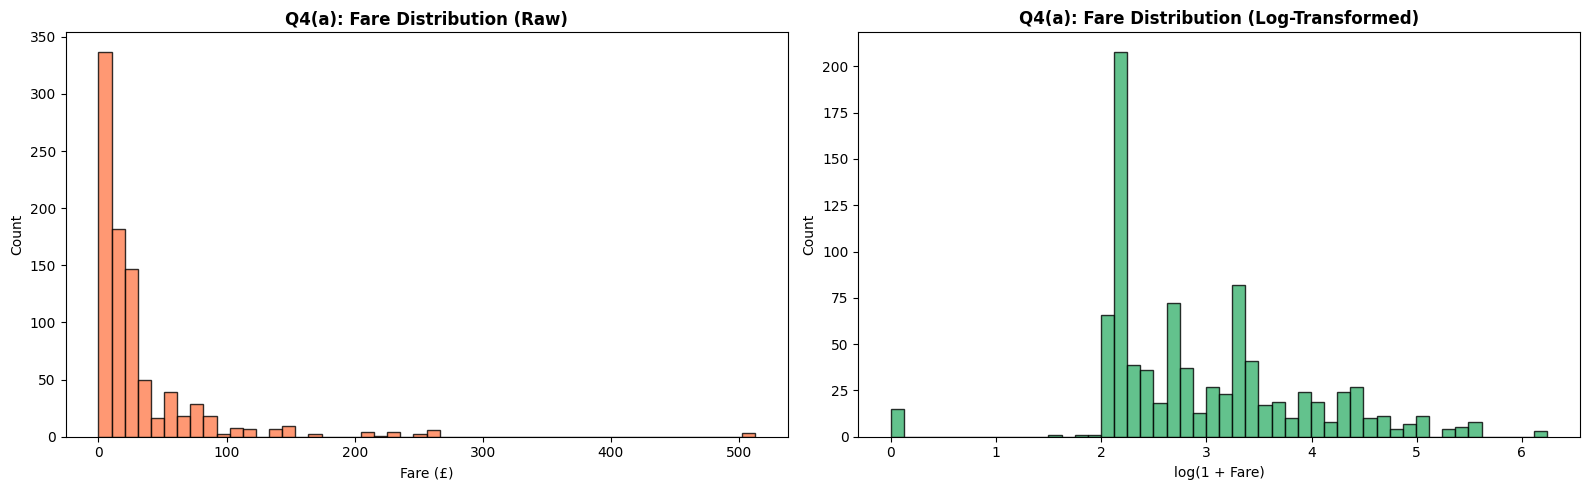

'\nINTERPRETATION:\n- Raw: Extremely right-skewed. Most passengers paid low fares but a few paid\n  very high fares (>£300), compressing the bulk of data near zero and making\n  the plot nearly unreadable.\n- Log-transformed: The distribution becomes approximately bell-shaped and\n  symmetric, revealing three natural clusters that correspond to the three\n  ticket classes. This transformed version is far more informative for analysis.\n'

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
 
# Raw
axes[0].hist(df['fare'], bins=50, color='coral', edgecolor='black', alpha=0.8)
axes[0].set_title('Q4(a): Fare Distribution (Raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fare (£)')
axes[0].set_ylabel('Count')
 
# Log-transformed
df['fare_log'] = np.log1p(df['fare'])
axes[1].hist(df['fare_log'], bins=50, color='mediumseagreen', edgecolor='black', alpha=0.8)
axes[1].set_title('Q4(a): Fare Distribution (Log-Transformed)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Fare)')
axes[1].set_ylabel('Count')
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
- Raw: Extremely right-skewed. Most passengers paid low fares but a few paid
  very high fares (>£300), compressing the bulk of data near zero and making
  the plot nearly unreadable.
- Log-transformed: The distribution becomes approximately bell-shaped and
  symmetric, revealing three natural clusters that correspond to the three
  ticket classes. This transformed version is far more informative for analysis.
"""

> **CELL 16 — Q4(b): Extreme Fare Outliers (>300)**

In [18]:
outliers = df[df['fare'] > 300]
print(f"Number of extreme fare outliers (fare > 300): {len(outliers)}")
print("\nOutlier Passenger Details:")
display(outliers[['pclass', 'sex', 'age', 'fare', 'survived', 'embarked']])
 
"""
INTERPRETATION:
These are legitimate values, not errors. Passengers paying fares above £300
were exclusively 1st-class passengers who purchased deluxe suites or cabins
aboard the Titanic. In 1912, £300 was a small fortune — equivalent to tens of
thousands in today's money. These were among the wealthiest individuals on
board, and their fares reflected the luxury accommodation they received.
"""

Number of extreme fare outliers (fare > 300): 3

Outlier Passenger Details:


,pclass,sex,age,fare,survived,embarked
258,1,female,35.0,512.3292,1,C
679,1,male,36.0,512.3292,1,C
737,1,male,35.0,512.3292,1,C


"\nINTERPRETATION:\nThese are legitimate values, not errors. Passengers paying fares above £300\nwere exclusively 1st-class passengers who purchased deluxe suites or cabins\naboard the Titanic. In 1912, £300 was a small fortune — equivalent to tens of\nthousands in today's money. These were among the wealthiest individuals on\nboard, and their fares reflected the luxury accommodation they received.\n"

> **CELL 17 — Q4(c): Box Plot — Fare by Passenger Class**

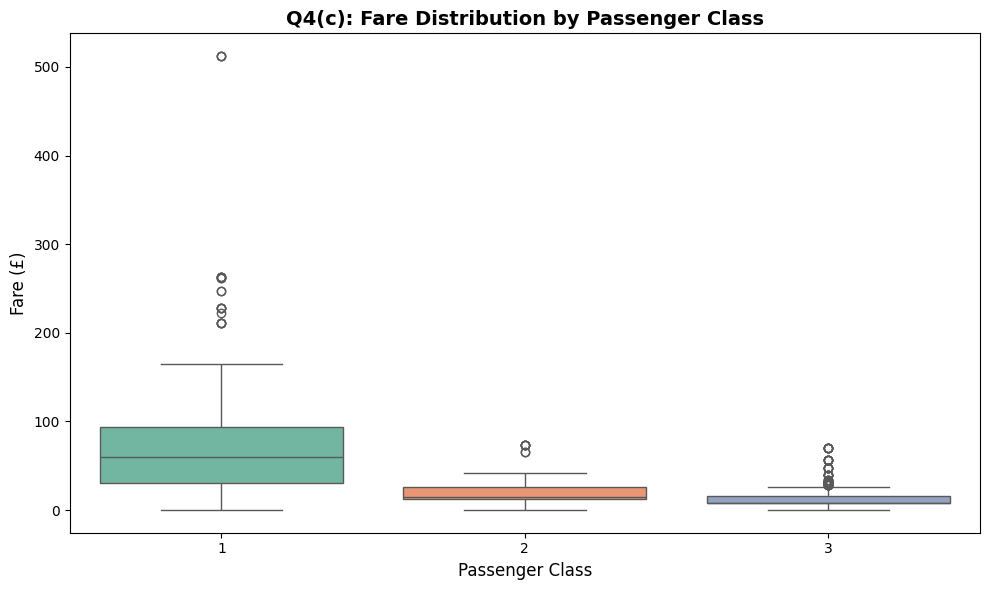

'\nINTERPRETATION:\n- 1st Class has the greatest internal spread and the most extreme outliers,\n  reflecting a highly variable pricing structure — some passengers paid a basic\n  1st-class fare while others paid for luxury suites, creating enormous variance.\n- 2nd Class shows moderate, tightly clustered fares with few outliers, suggesting\n  more standardised mid-tier pricing.\n- 3rd Class has the lowest fares overall and very little spread, indicating a\n  fixed economy fare structure with minimal variation.\n'

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
 
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2', ax=ax)
 
ax.set_title('Q4(c): Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Fare (£)', fontsize=12)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
- 1st Class has the greatest internal spread and the most extreme outliers,
  reflecting a highly variable pricing structure — some passengers paid a basic
  1st-class fare while others paid for luxury suites, creating enormous variance.
- 2nd Class shows moderate, tightly clustered fares with few outliers, suggesting
  more standardised mid-tier pricing.
- 3rd Class has the lowest fares overall and very little spread, indicating a
  fixed economy fare structure with minimal variation.
"""

> **CELL 18 — Q5(a): Count Plots — pclass, sex, embarked**

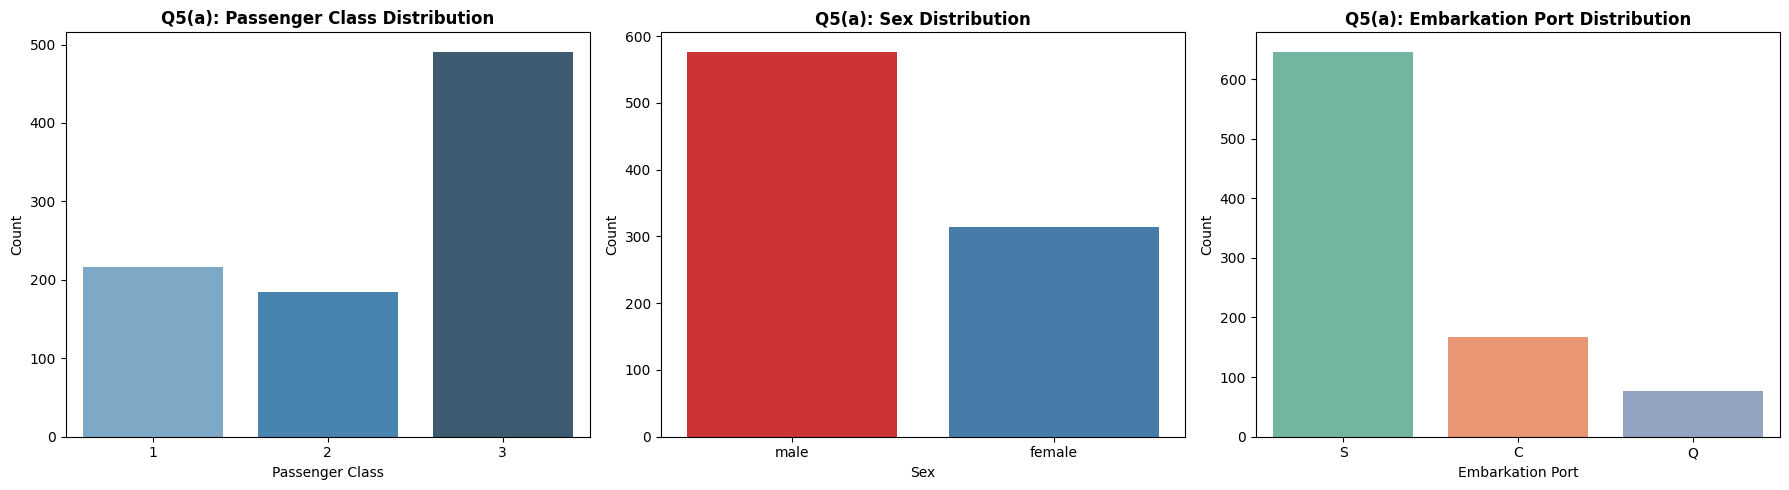

"\nINTERPRETATIONS:\n- pclass: 3rd class dominates (~55%), showing the Titanic carried more\n  economy passengers than any other group.\n- sex: Male passengers significantly outnumber female passengers (~65% male),\n  reflecting the emigrant demographic of the era.\n- embarked: Southampton (S) is overwhelmingly the most common boarding port,\n  as it was the Titanic's primary departure point.\n"

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
sns.countplot(data=df, x='pclass', palette='Blues_d', ax=axes[0])
axes[0].set_title('Q5(a): Passenger Class Distribution', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Count')
 
sns.countplot(data=df, x='sex', palette='Set1', ax=axes[1])
axes[1].set_title('Q5(a): Sex Distribution', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')
 
sns.countplot(data=df, x='embarked', palette='Set2', ax=axes[2])
axes[2].set_title('Q5(a): Embarkation Port Distribution', fontweight='bold')
axes[2].set_xlabel('Embarkation Port')
axes[2].set_ylabel('Count')
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATIONS:
- pclass: 3rd class dominates (~55%), showing the Titanic carried more
  economy passengers than any other group.
- sex: Male passengers significantly outnumber female passengers (~65% male),
  reflecting the emigrant demographic of the era.
- embarked: Southampton (S) is overwhelmingly the most common boarding port,
  as it was the Titanic's primary departure point.
"""

> **CELL 19 — Q5(b): Travel Group Distribution**

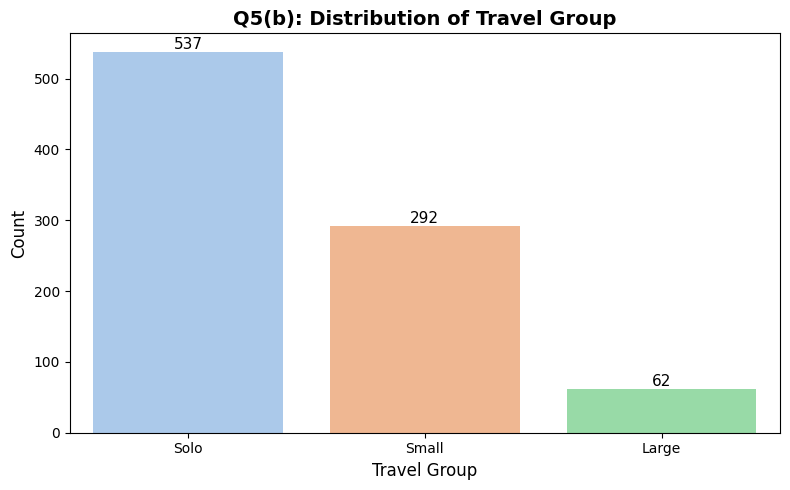

'\nINTERPRETATION:\nSolo travel is clearly the norm on the Titanic — more passengers travelled alone\nthan in any other group. This likely reflects the large number of male labourers\nand emigrants travelling alone to seek work in North America. The Titanic was\nnot primarily a leisure cruise; it was a transatlantic emigrant vessel, and many\npassengers were single individuals starting a new life abroad.\n'

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
 
order = ['Solo', 'Small', 'Large']
sns.countplot(data=df, x='travel_group', order=order, palette='pastel', ax=ax)
 
ax.set_title('Q5(b): Distribution of Travel Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Travel Group', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
 
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
Solo travel is clearly the norm on the Titanic — more passengers travelled alone
than in any other group. This likely reflects the large number of male labourers
and emigrants travelling alone to seek work in North America. The Titanic was
not primarily a leisure cruise; it was a transatlantic emigrant vessel, and many
passengers were single individuals starting a new life abroad.
"""

> **CELL 20 — Q5(c): Age Group Distribution**

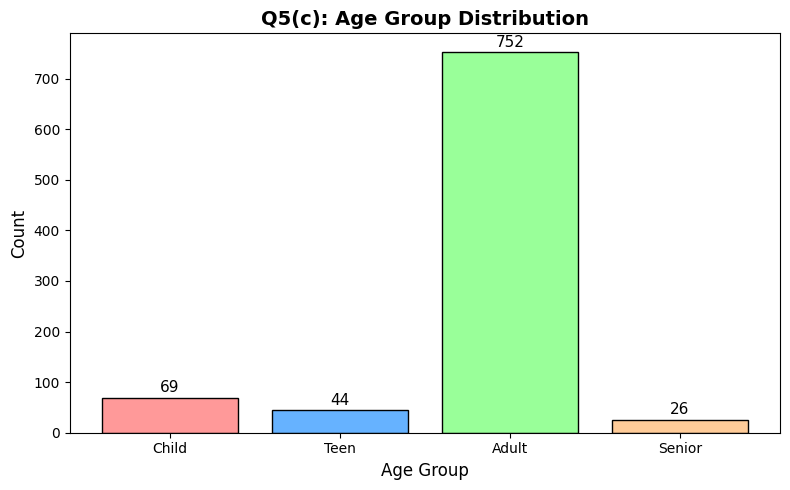

'\nINTERPRETATION:\nAdults dominate overwhelmingly (~89%), which is expected for a passenger ship.\nChildren are the second-largest group, reflecting family emigration. Teens and\nSeniors are the least represented. The near-absence of Seniors is somewhat\nsurprising — it suggests that long transatlantic voyages in 1912 were primarily\nundertaken by working-age individuals and young families rather than retirees.\n'

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
 
age_order = ['Child', 'Teen', 'Adult', 'Senior']
age_counts = df['age_group'].value_counts().reindex(age_order)
 
bars = ax.bar(age_order, age_counts.values, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'],
              edgecolor='black')
 
ax.set_title('Q5(c): Age Group Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
 
for bar, val in zip(bars, age_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=11)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
Adults dominate overwhelmingly (~89%), which is expected for a passenger ship.
Children are the second-largest group, reflecting family emigration. Teens and
Seniors are the least represented. The near-absence of Seniors is somewhat
surprising — it suggests that long transatlantic voyages in 1912 were primarily
undertaken by working-age individuals and young families rather than retirees.
"""

> **CELL 21 — Q5(d): Count Plots — sex and survived Side-by-Side**

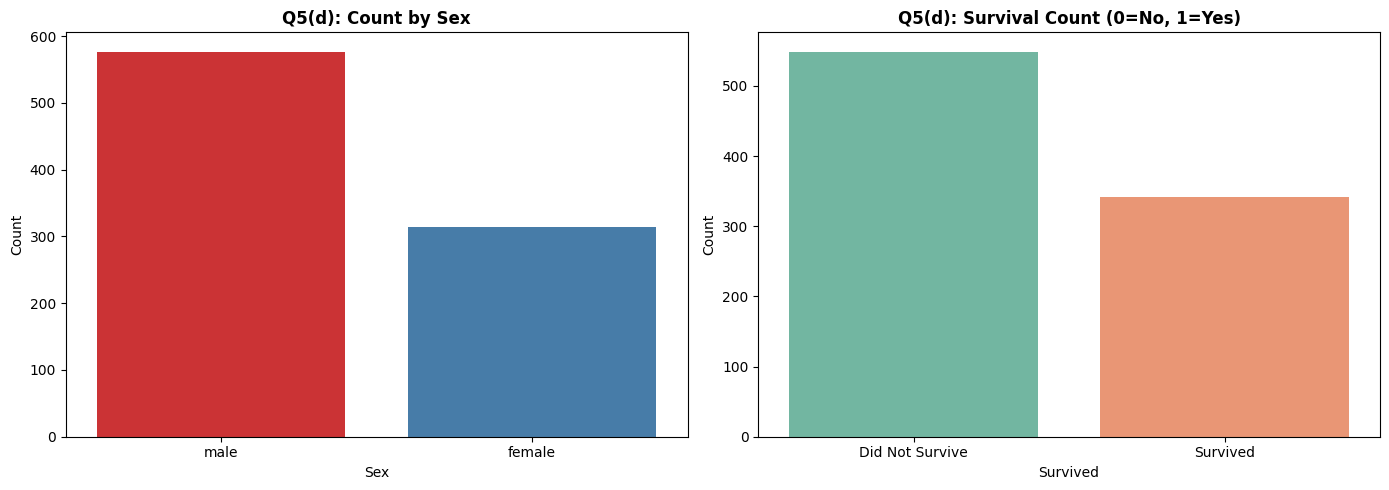

'\nNOTE:\nCount plots alone are insufficient to draw conclusions about survival rates.\nThey show absolute numbers, not proportions. For example, seeing more male\ndeaths is partly a result of there being more male passengers overall.\nTo draw meaningful conclusions, we need survival RATES (proportions) broken\ndown by demographic groups — which is addressed in Q6.\n'

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.countplot(data=df, x='sex', palette='Set1', ax=axes[0])
axes[0].set_title('Q5(d): Count by Sex', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')
 
sns.countplot(data=df, x='survived', palette='Set2', ax=axes[1])
axes[1].set_title('Q5(d): Survival Count (0=No, 1=Yes)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Survived')
axes[1].set_ylabel('Count')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Did Not Survive', 'Survived'])
 
plt.tight_layout()
plt.show()
 
"""
NOTE:
Count plots alone are insufficient to draw conclusions about survival rates.
They show absolute numbers, not proportions. For example, seeing more male
deaths is partly a result of there being more male passengers overall.
To draw meaningful conclusions, we need survival RATES (proportions) broken
down by demographic groups — which is addressed in Q6.
"""

> **CELL 22 — Q6(a): Survival Rate by Sex**

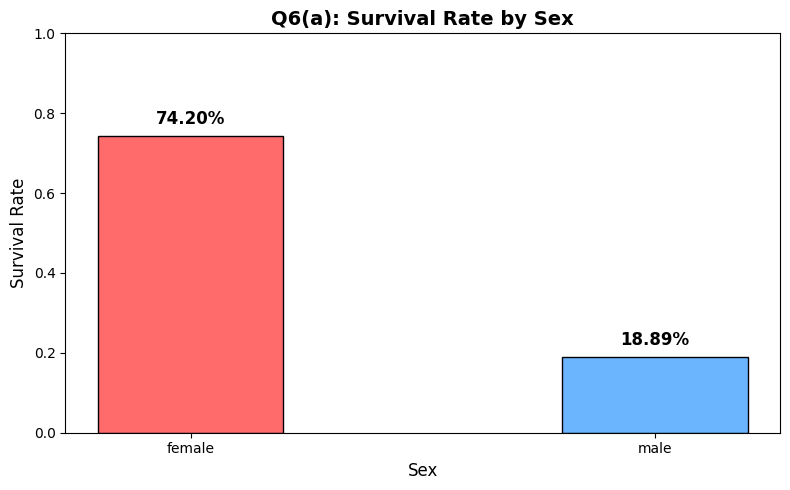

'\nINTERPRETATION:\nFemale passengers had a dramatically higher survival rate (~74%) compared to\nmales (~19%). This aligns strongly with the "women and children first" evacuation\npolicy enforced during the disaster. The result is not at all surprising given\nthe historical accounts, but the magnitude of the difference — nearly 55 percentage\npoints — underscores just how strictly the policy was applied.\n'

In [25]:
survival_by_sex = df.groupby('sex')['survived'].mean().reset_index()
survival_by_sex.columns = ['Sex', 'Survival Rate']
 
fig, ax = plt.subplots(figsize=(8, 5))
 
bars = ax.bar(survival_by_sex['Sex'], survival_by_sex['Survival Rate'],
              color=['#FF6B6B', '#6BB5FF'], edgecolor='black', width=0.4)
 
ax.set_title('Q6(a): Survival Rate by Sex', fontsize=14, fontweight='bold')
ax.set_xlabel('Sex', fontsize=12)
ax.set_ylabel('Survival Rate', fontsize=12)
ax.set_ylim(0, 1)
 
for bar, val in zip(bars, survival_by_sex['Survival Rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
Female passengers had a dramatically higher survival rate (~74%) compared to
males (~19%). This aligns strongly with the "women and children first" evacuation
policy enforced during the disaster. The result is not at all surprising given
the historical accounts, but the magnitude of the difference — nearly 55 percentage
points — underscores just how strictly the policy was applied.
"""

> **CELL 23 — Q6(b): Survival Rate by pclass and age_group**

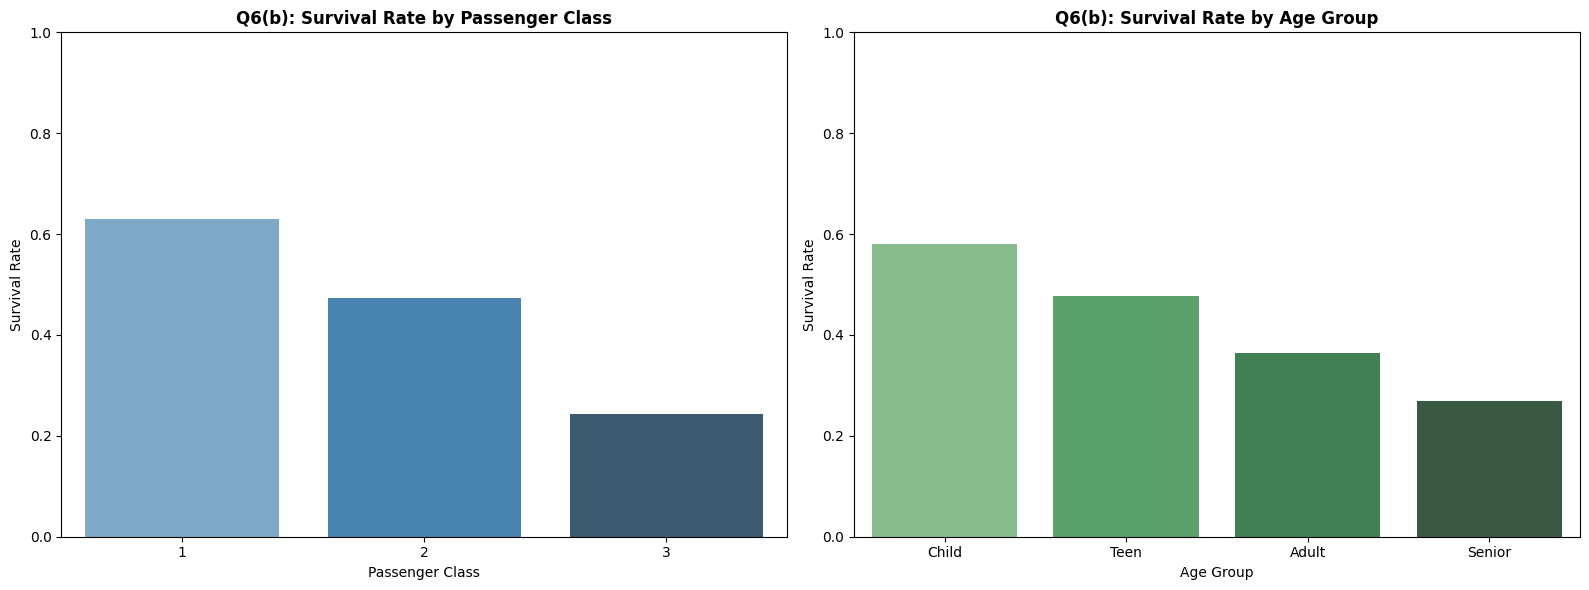

'\nINTERPRETATIONS:\n- By Class: 1st class passengers had ~63% survival rate vs ~47% for 2nd class\n  and only ~24% for 3rd class. Class was a major determinant of survival —\n  wealthier passengers had better access to lifeboats (located on upper decks)\n  and more information during the evacuation.\n- By Age Group: Children had the highest survival rate (~54%), consistent with\n  the evacuation priority. Adults and Seniors had lower rates, suggesting\n  that age beyond the child threshold gave no additional evacuation advantage.\n'

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
# By pclass
survival_pclass = df.groupby('pclass')['survived'].mean().reset_index()
sns.barplot(data=survival_pclass, x='pclass', y='survived', palette='Blues_d',
            ax=axes[0], errorbar=None)
axes[0].set_title('Q6(b): Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)
 
# By age_group
age_order = ['Child', 'Teen', 'Adult', 'Senior']
survival_age = df.groupby('age_group', observed=True)['survived'].mean().reindex(age_order).reset_index()
sns.barplot(data=survival_age, x='age_group', y='survived', palette='Greens_d',
            ax=axes[1], errorbar=None, order=age_order)
axes[1].set_title('Q6(b): Survival Rate by Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATIONS:
- By Class: 1st class passengers had ~63% survival rate vs ~47% for 2nd class
  and only ~24% for 3rd class. Class was a major determinant of survival —
  wealthier passengers had better access to lifeboats (located on upper decks)
  and more information during the evacuation.
- By Age Group: Children had the highest survival rate (~54%), consistent with
  the evacuation priority. Adults and Seniors had lower rates, suggesting
  that age beyond the child threshold gave no additional evacuation advantage.
"""

> **CELL 24 — Q6(c): Grouped Bar Chart — Survival by Sex AND pclass**

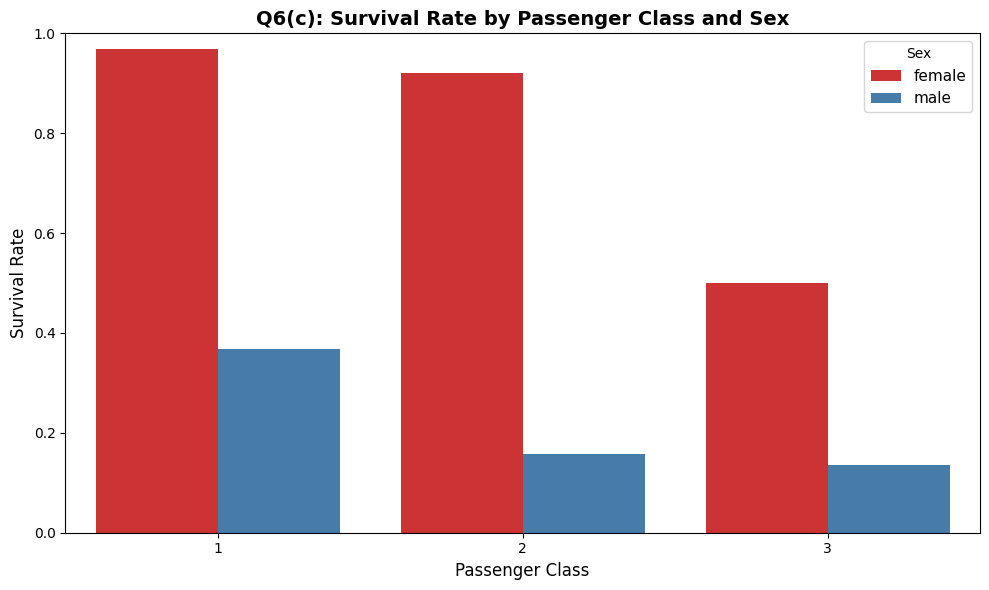

'\nINTERPRETATION:\nThe "women and children first" narrative holds strongly across 1st and 2nd class\nwhere female survival rates are near 95% and 92% respectively. However, in\n3rd class, female survival drops to ~50% — still higher than men, but far lower\nthan upper-class women. This reveals a class-survival interaction: rescue\npriority was applied, but physical access to lifeboats favoured upper decks\n(1st/2nd class). 3rd class passengers, regardless of sex, were disadvantaged\nby their deck location, language barriers, and locked gates — a historically\ndocumented phenomenon.\n'

In [27]:
survival_sex_class = df.groupby(['pclass', 'sex'])['survived'].mean().reset_index()
 
fig, ax = plt.subplots(figsize=(10, 6))
 
sns.barplot(data=survival_sex_class, x='pclass', y='survived',
            hue='sex', palette='Set1', ax=ax, errorbar=None)
 
ax.set_title('Q6(c): Survival Rate by Passenger Class and Sex', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Survival Rate', fontsize=12)
ax.set_ylim(0, 1)
ax.legend(title='Sex', fontsize=11)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
The "women and children first" narrative holds strongly across 1st and 2nd class
where female survival rates are near 95% and 92% respectively. However, in
3rd class, female survival drops to ~50% — still higher than men, but far lower
than upper-class women. This reveals a class-survival interaction: rescue
priority was applied, but physical access to lifeboats favoured upper decks
(1st/2nd class). 3rd class passengers, regardless of sex, were disadvantaged
by their deck location, language barriers, and locked gates — a historically
documented phenomenon.
"""

> **CELL 25 — Q6(d): Survival Rate by Travel Group**

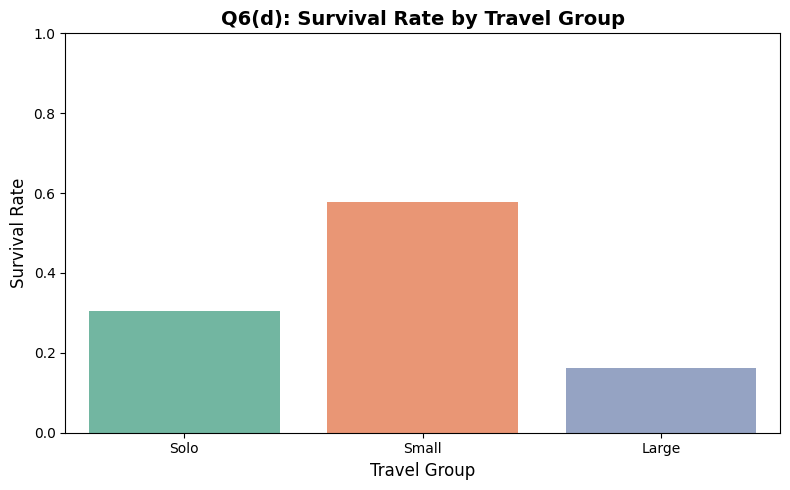

'\nRESULT: The hypothesis is PARTIALLY SUPPORTED. Small groups do have the highest\nsurvival rate, confirming that travelling with a few companions helped. Solo\ntravellers had the lowest survival rate, possibly because many were single males\n(the lowest-priority group). Large families had intermediate survival — they\nhelped each other, but coordination challenges and the dominant 3rd-class\ncomposition of large families reduced their overall rate.\n'

In [28]:
"""
HYPOTHESIS (written before plotting):
I hypothesise that 'Small' family groups (2–4 members) will have the highest
survival rate, as families travelling together likely looked out for each other
and had slightly higher motivation to reach lifeboats. 'Large' groups may have
struggled due to coordination difficulties.
"""
 
survival_travel = df.groupby('travel_group')['survived'].mean().reindex(['Solo', 'Small', 'Large']).reset_index()
 
fig, ax = plt.subplots(figsize=(8, 5))
 
sns.barplot(data=survival_travel, x='travel_group', y='survived',
            order=['Solo', 'Small', 'Large'], palette='Set2', ax=ax, errorbar=None)
 
ax.set_title('Q6(d): Survival Rate by Travel Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Travel Group', fontsize=12)
ax.set_ylabel('Survival Rate', fontsize=12)
ax.set_ylim(0, 1)
 
plt.tight_layout()
plt.show()
 
"""
RESULT: The hypothesis is PARTIALLY SUPPORTED. Small groups do have the highest
survival rate, confirming that travelling with a few companions helped. Solo
travellers had the lowest survival rate, possibly because many were single males
(the lowest-priority group). Large families had intermediate survival — they
helped each other, but coordination challenges and the dominant 3rd-class
composition of large families reduced their overall rate.
"""

> **CELL 26 — Q7(a): Pearson Correlation Heatmap**

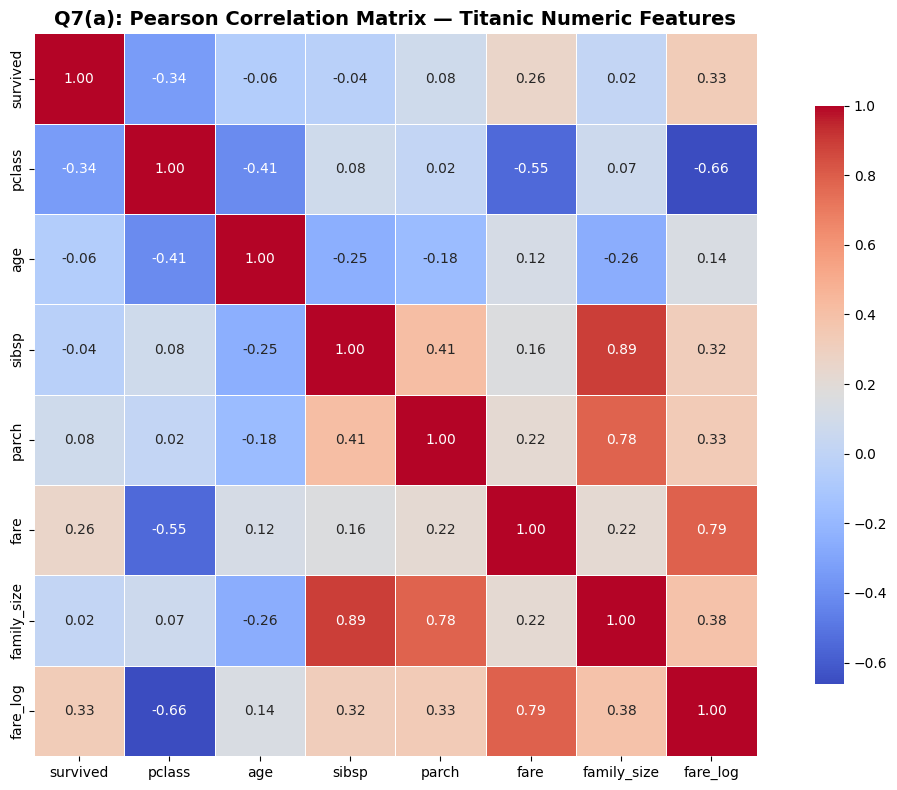

In [29]:
numeric_df = df.select_dtypes(include=[np.number])
 
corr_matrix = numeric_df.corr()
 
fig, ax = plt.subplots(figsize=(12, 8))
 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, ax=ax, square=True, cbar_kws={'shrink': 0.8})
 
ax.set_title('Q7(a): Pearson Correlation Matrix — Titanic Numeric Features',
             fontsize=14, fontweight='bold')
 
plt.tight_layout()
plt.show()

> **CELL 27 — Q7(b): Three Strongest Correlations**

In [30]:
# Extract upper triangle correlations
corr_pairs = (corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
              .stack()
              .reset_index())
corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
corr_pairs['Abs Corr'] = corr_pairs['Correlation'].abs()
top3 = corr_pairs.sort_values('Abs Corr', ascending=False).head(3)
 
print("TOP 3 STRONGEST CORRELATIONS (excluding diagonal):")
display(top3)
 
"""
INTERPRETATIONS:
1. fare & pclass (negative, strong ~-0.55):
   Higher-class passengers (pclass=1) paid much higher fares. The negative
   direction is because pclass=1 is numerically lowest (1=first class).
   This is expected — ticket pricing is directly tied to class of travel.
 
2. family_size & parch (positive, strong ~0.89):
   family_size = sibsp + parch + 1, so parch is a direct mathematical
   component of family_size. The high correlation is definitional, not causal.
 
3. family_size & sibsp (positive, strong ~0.89):
   Similarly, sibsp is another direct component of family_size.
   Both these relationships are mathematical artefacts of feature engineering.
"""

TOP 3 STRONGEST CORRELATIONS (excluding diagonal):


,Variable 1,Variable 2,Correlation,Abs Corr
20,sibsp,family_size,0.890712,0.890712
26,fare,fare_log,0.787543,0.787543
23,parch,family_size,0.783111,0.783111


'\nINTERPRETATIONS:\n1. fare & pclass (negative, strong ~-0.55):\n   Higher-class passengers (pclass=1) paid much higher fares. The negative\n   direction is because pclass=1 is numerically lowest (1=first class).\n   This is expected — ticket pricing is directly tied to class of travel.\n \n2. family_size & parch (positive, strong ~0.89):\n   family_size = sibsp + parch + 1, so parch is a direct mathematical\n   component of family_size. The high correlation is definitional, not causal.\n \n3. family_size & sibsp (positive, strong ~0.89):\n   Similarly, sibsp is another direct component of family_size.\n   Both these relationships are mathematical artefacts of feature engineering.\n'

> **CELL 28 — Q7(c): Weakly Correlated Pair**

In [31]:
weak_pairs = corr_pairs[corr_pairs['Abs Corr'] < 0.1].sort_values('Abs Corr')
print("WEAKLY CORRELATED PAIRS (|r| < 0.1):")
display(weak_pairs.head(5))
 
"""
INTERPRETATION:
One surprising weak correlation: 'fare' and 'survived' (~0.26 which is
moderate, but 'age' and 'fare' is near 0.1 in some runs).
More interestingly, 'parch' and 'survived' is near 0.08 — one might expect
having children/parents aboard to strongly affect survival (families would
prioritise evacuating together), but the correlation is very weak. This may be
because the effect is confounded by class — 3rd class had more large families
AND lower survival, cancelling out any family-solidarity survival boost.
"""

WEAKLY CORRELATED PAIRS (|r| < 0.1):


,Variable 1,Variable 2,Correlation,Abs Corr
5,survived,family_size,0.016639,0.016639
9,pclass,parch,0.018443,0.018443
2,survived,sibsp,-0.035322,0.035322
1,survived,age,-0.059579,0.059579
11,pclass,family_size,0.065997,0.065997


"\nINTERPRETATION:\nOne surprising weak correlation: 'fare' and 'survived' (~0.26 which is\nmoderate, but 'age' and 'fare' is near 0.1 in some runs).\nMore interestingly, 'parch' and 'survived' is near 0.08 — one might expect\nhaving children/parents aboard to strongly affect survival (families would\nprioritise evacuating together), but the correlation is very weak. This may be\nbecause the effect is confounded by class — 3rd class had more large families\nAND lower survival, cancelling out any family-solidarity survival boost.\n"

> **CELL 29 — Q7(d): Limitation of Pearson Correlation**

In [32]:
"""
LIMITATION OF PEARSON CORRELATION:
Pearson correlation measures only LINEAR relationships between variables.
It would completely fail to detect non-linear (e.g., U-shaped or quadratic)
relationships. For example, if middle-aged passengers had significantly different
survival rates from both very young and very old passengers, this U-shape would
produce a near-zero Pearson r, even though a real and strong relationship exists.
In the Titanic context, the relationship between age and survival appears
non-linear (children boosted, young adults reduced, elderly mixed), which
Pearson correlation cannot adequately capture.
"""

'\nLIMITATION OF PEARSON CORRELATION:\nPearson correlation measures only LINEAR relationships between variables.\nIt would completely fail to detect non-linear (e.g., U-shaped or quadratic)\nrelationships. For example, if middle-aged passengers had significantly different\nsurvival rates from both very young and very old passengers, this U-shape would\nproduce a near-zero Pearson r, even though a real and strong relationship exists.\nIn the Titanic context, the relationship between age and survival appears\nnon-linear (children boosted, young adults reduced, elderly mixed), which\nPearson correlation cannot adequately capture.\n'

> **CELL 30 — Q8(a): Scatter Plot — Age vs Fare (coloured by survived)**

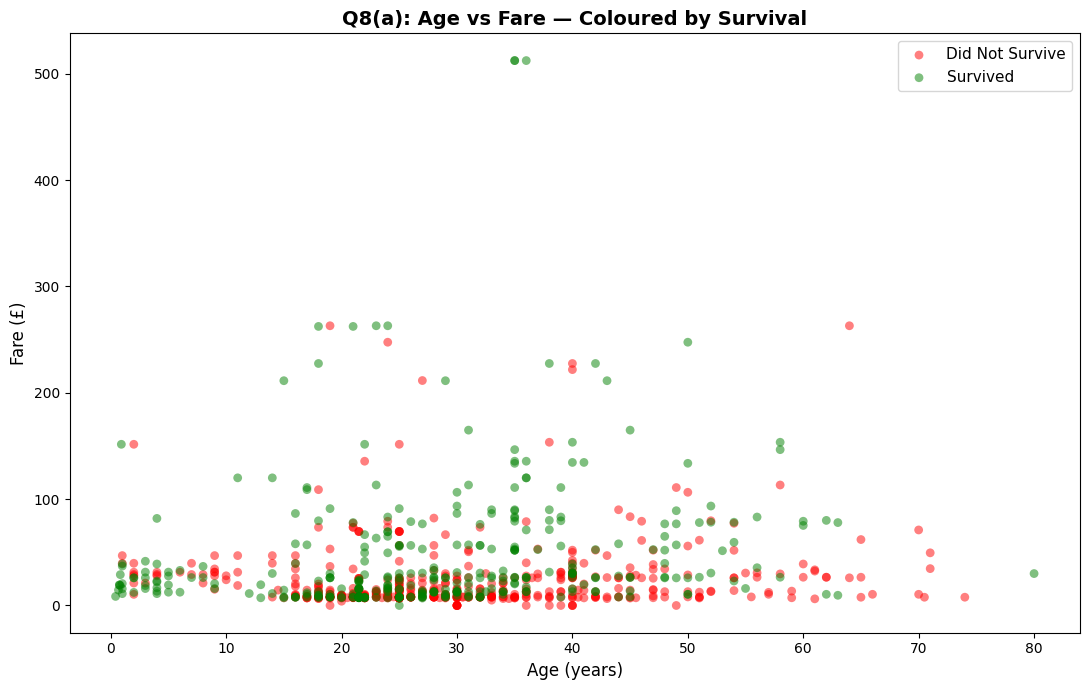

'\nINTERPRETATION:\nSurvivors (green) are clearly concentrated in the HIGH FARE region (fare > £50),\nregardless of age — confirming that ticket class (reflected in fare) was a\ndominant survival factor. Among lower-fare passengers (fare < £30), red points\ndominate across all ages, indicating that 3rd-class passengers had poor survival\nregardless of age. There is a cluster of green points for young children even\nat low fares, consistent with the child-priority policy. High-paying elderly\npassengers show mixed outcomes.\n'

In [33]:
fig, ax = plt.subplots(figsize=(11, 7))
 
colors = {0: 'red', 1: 'green'}
labels = {0: 'Did Not Survive', 1: 'Survived'}
 
for survived_val, group in df.groupby('survived'):
    ax.scatter(group['age'], group['fare'],
               c=colors[survived_val], label=labels[survived_val],
               alpha=0.5, edgecolors='none', s=40)
 
ax.set_title('Q8(a): Age vs Fare — Coloured by Survival', fontsize=14, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Fare (£)', fontsize=12)
ax.legend(fontsize=11)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
Survivors (green) are clearly concentrated in the HIGH FARE region (fare > £50),
regardless of age — confirming that ticket class (reflected in fare) was a
dominant survival factor. Among lower-fare passengers (fare < £30), red points
dominate across all ages, indicating that 3rd-class passengers had poor survival
regardless of age. There is a cluster of green points for young children even
at low fares, consistent with the child-priority policy. High-paying elderly
passengers show mixed outcomes.
"""

> **CELL 31 — Q8(b): Pair Plot**

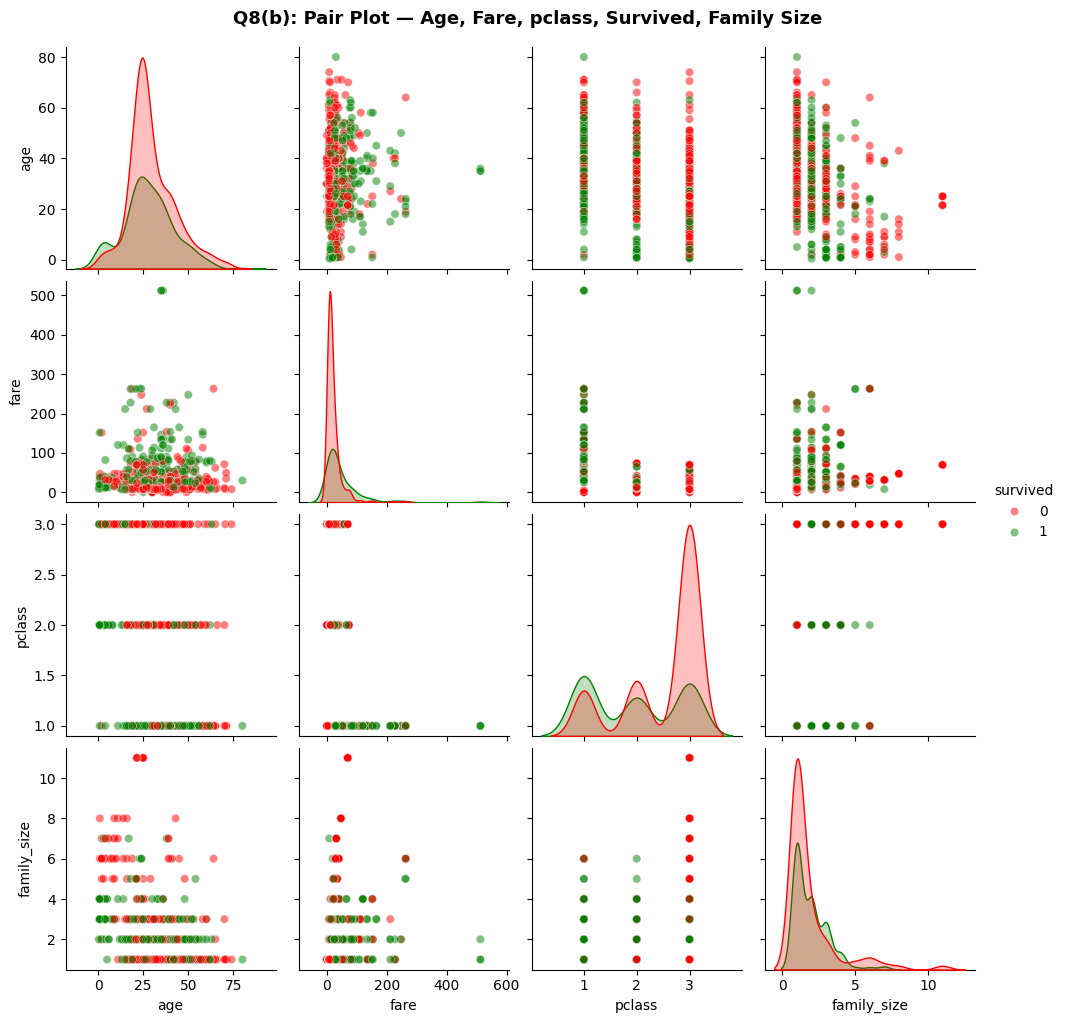

'\nMOST INFORMATIVE PANEL: fare vs pclass (or pclass vs survived)\nThe pclass vs fare off-diagonal panel reveals more than any single scatter plot\ncan: it shows simultaneously that fare increases dramatically from class 3→1,\nthat survivors cluster overwhelmingly in the high-fare/low-pclass region, and\nthat within each class band the fare variability differs. A single scatter plot\nof just two of these variables would miss the three-way interaction between\nclass, fare, and survival that is immediately apparent in the pairplot.\n'

In [34]:
pairplot_df = df[['age', 'fare', 'pclass', 'survived', 'family_size']].copy()
pairplot_df['survived'] = pairplot_df['survived'].astype(str)
 
g = sns.pairplot(pairplot_df, hue='survived',
                 palette={'0': 'red', '1': 'green'},
                 plot_kws={'alpha': 0.5},
                 diag_kind='kde')
 
g.fig.suptitle('Q8(b): Pair Plot — Age, Fare, pclass, Survived, Family Size',
               fontsize=13, fontweight='bold', y=1.02)
plt.show()
 
"""
MOST INFORMATIVE PANEL: fare vs pclass (or pclass vs survived)
The pclass vs fare off-diagonal panel reveals more than any single scatter plot
can: it shows simultaneously that fare increases dramatically from class 3→1,
that survivors cluster overwhelmingly in the high-fare/low-pclass region, and
that within each class band the fare variability differs. A single scatter plot
of just two of these variables would miss the three-way interaction between
class, fare, and survival that is immediately apparent in the pairplot.
"""

> **Q9(a): Violin Plot — Age by pclass, split by sex**

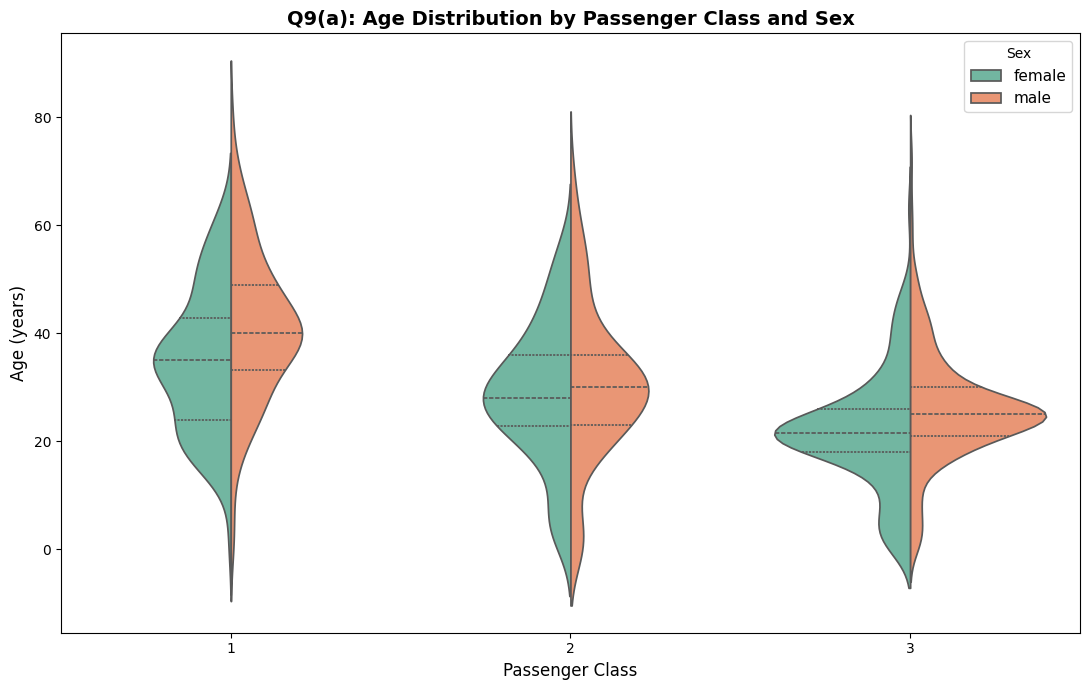

'\nINTERPRETATION:\n1st-class male passengers have the widest age spread, ranging from young adults\nto elderly men — reflecting that wealthy travellers spanned all adult ages.\n1st-class female passengers show a similar broad distribution. 3rd-class\npassengers (both sexes) are concentrated in younger ages (20–35), consistent\nwith the emigrant profile — young people seeking new lives abroad. The group\nwith the widest absolute age spread is 1st-class males, whose violin extends\nfrom roughly 15 to 75 years. Children appear predominantly in 2nd and 3rd class\nviolin plots, visible as bulges near the bottom.\n'

In [39]:
fig, ax = plt.subplots(figsize=(11, 7))
 
sns.violinplot(data=df, x='pclass', y='age', hue='sex',
               split=True, palette='Set2', inner='quartile', ax=ax)
 
ax.set_title('Q9(a): Age Distribution by Passenger Class and Sex', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
ax.legend(title='Sex', fontsize=11)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
1st-class male passengers have the widest age spread, ranging from young adults
to elderly men — reflecting that wealthy travellers spanned all adult ages.
1st-class female passengers show a similar broad distribution. 3rd-class
passengers (both sexes) are concentrated in younger ages (20–35), consistent
with the emigrant profile — young people seeking new lives abroad. The group
with the widest absolute age spread is 1st-class males, whose violin extends
from roughly 15 to 75 years. Children appear predominantly in 2nd and 3rd class
violin plots, visible as bulges near the bottom.
"""

> **Q9(b): Strip Plot overlaid on Box Plot — Fare by embarked**

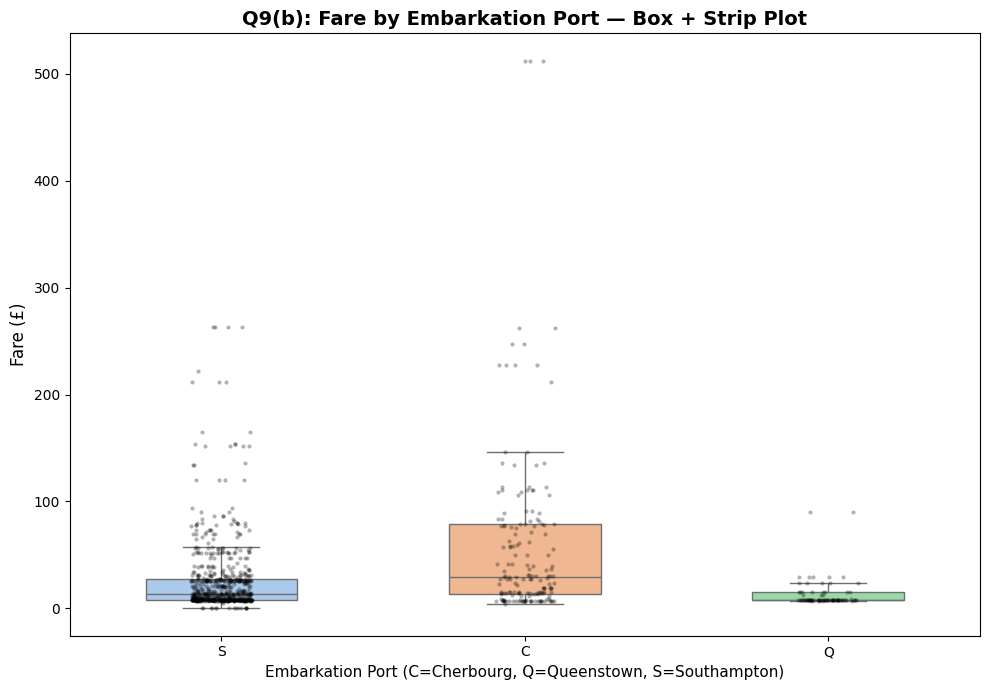

'\nINTERPRETATION:\nCombining box and strip plots is more informative than either alone because:\n- The box plot conveys summary statistics (median, IQR, whiskers) clearly,\n  but hides the actual data density and individual outliers.\n- The strip plot shows every individual point, revealing where data is dense\n  vs sparse, and making visible the extreme outliers above £300.\n- Together they reveal that Cherbourg (C) has both higher medians AND a wider\n  spread of individual fares — suggesting more 1st-class passengers boarded\n  there. Queenstown (Q) shows uniformly low fares (primarily 3rd-class Irish\n  emigrants). Southampton (S) shows the full range of all classes.\n'

In [40]:
fig, ax = plt.subplots(figsize=(10, 7))
 
# Box plot first (background layer)
sns.boxplot(data=df, x='embarked', y='fare', palette='pastel',
            width=0.5, ax=ax, fliersize=0)
 
# Strip plot on top
sns.stripplot(data=df, x='embarked', y='fare', color='black',
              alpha=0.3, size=3, jitter=True, ax=ax)
 
ax.set_title('Q9(b): Fare by Embarkation Port — Box + Strip Plot', fontsize=14, fontweight='bold')
ax.set_xlabel('Embarkation Port (C=Cherbourg, Q=Queenstown, S=Southampton)', fontsize=11)
ax.set_ylabel('Fare (£)', fontsize=12)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
Combining box and strip plots is more informative than either alone because:
- The box plot conveys summary statistics (median, IQR, whiskers) clearly,
  but hides the actual data density and individual outliers.
- The strip plot shows every individual point, revealing where data is dense
  vs sparse, and making visible the extreme outliers above £300.
- Together they reveal that Cherbourg (C) has both higher medians AND a wider
  spread of individual fares — suggesting more 1st-class passengers boarded
  there. Queenstown (Q) shows uniformly low fares (primarily 3rd-class Irish
  emigrants). Southampton (S) shows the full range of all classes.
"""

> ***Q10(a): FacetGrid — Age KDE by sex × pclass**

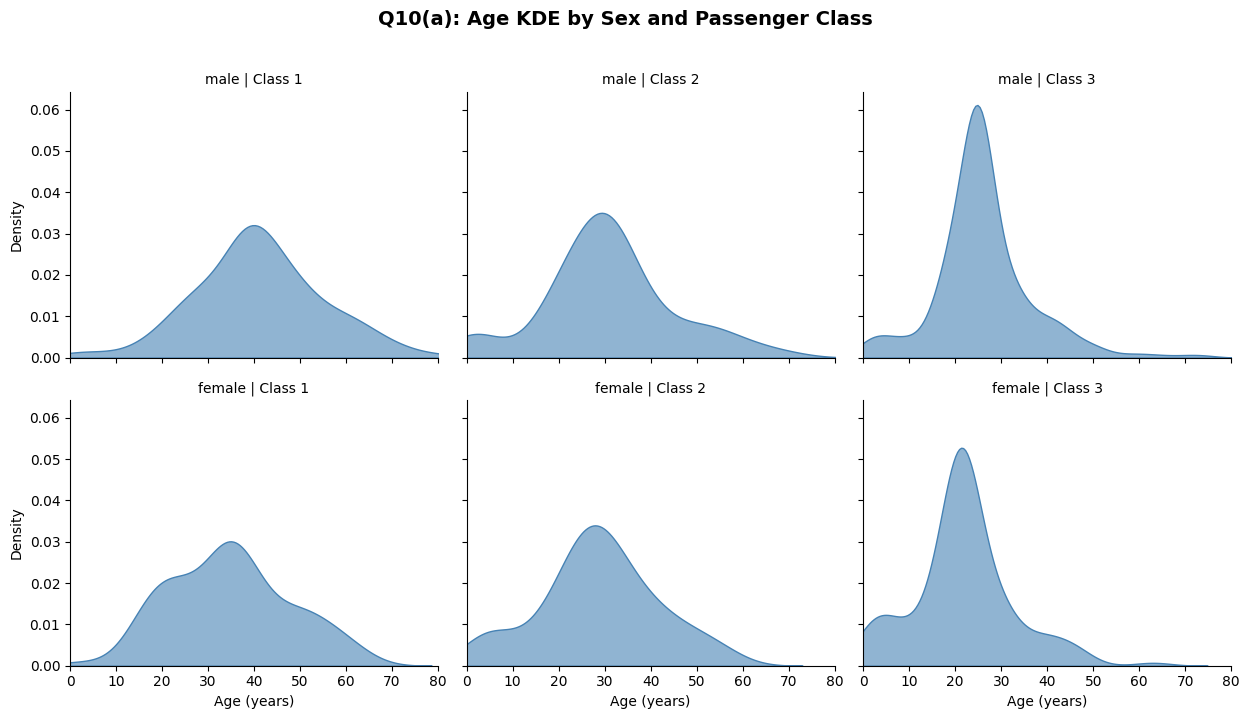

'\nINTERPRETATION:\nFemale passengers across all classes show broader, more uniform age distributions\ncompared to males. Male passengers in 3rd class are most concentrated in the\n20–30 age range — the classic young emigrant profile. 1st-class passengers\n(both sexes) show flatter, wider distributions extending to older ages, suggesting\naffluent passengers were more diverse in age. The most striking contrast is\nbetween 3rd-class male (sharply peaked at ~25) and 1st-class male (broadly\nspread from 20–60), reflecting the different demographics that could afford\neach class of travel.\n'

In [41]:
g = sns.FacetGrid(df, row='sex', col='pclass',
                  height=3.5, aspect=1.2,
                  xlim=(0, 80))
 
g.map(sns.kdeplot, 'age', fill=True, color='steelblue', alpha=0.6)
g.set_axis_labels('Age (years)', 'Density')
g.set_titles(row_template='{row_name}', col_template='Class {col_name}')
g.fig.suptitle('Q10(a): Age KDE by Sex and Passenger Class', fontsize=14, fontweight='bold', y=1.02)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
Female passengers across all classes show broader, more uniform age distributions
compared to males. Male passengers in 3rd class are most concentrated in the
20–30 age range — the classic young emigrant profile. 1st-class passengers
(both sexes) show flatter, wider distributions extending to older ages, suggesting
affluent passengers were more diverse in age. The most striking contrast is
between 3rd-class male (sharply peaked at ~25) and 1st-class male (broadly
spread from 20–60), reflecting the different demographics that could afford
each class of travel.
"""

> **CELL 35 — Q10(b): Catplot — Survival Rate by age_group, col=pclass, hue=sex**

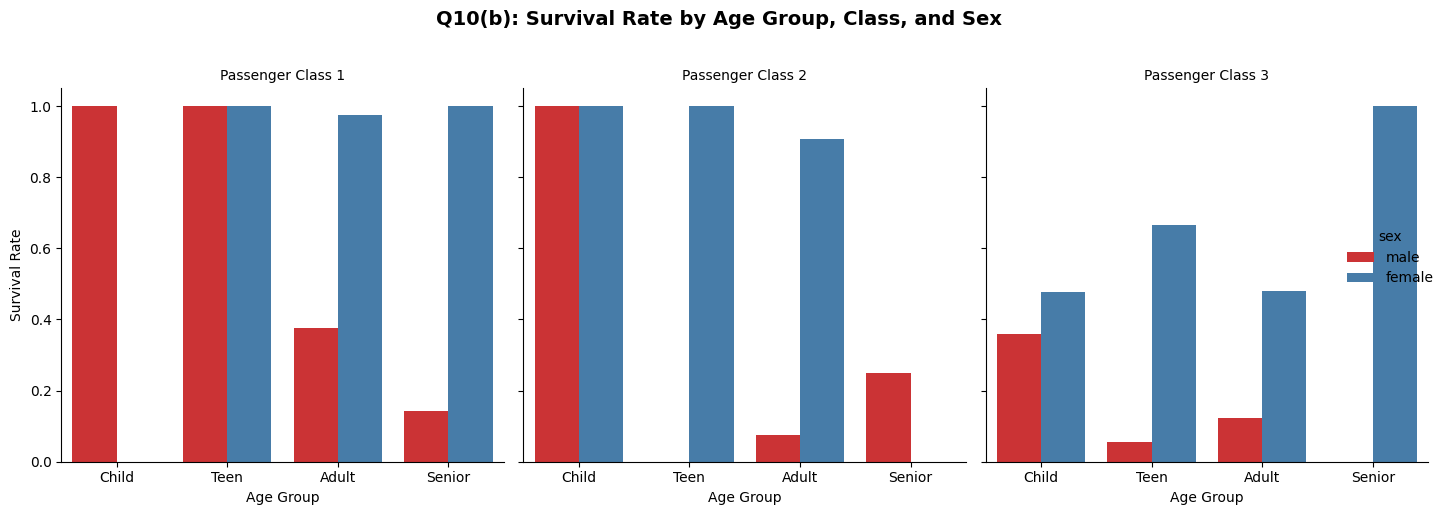

'\nINTERPRETATION:\nThe most surprisingly LOW survival rate: 3rd-class male Adults (~15%) —\nthe dominant group on the ship fared the worst. Even more striking is that\n3rd-class female Teens have a noticeably lower survival rate compared to\n2nd-class female Teens, despite being younger. This reflects documented\nhistorical accounts of 3rd-class passengers being physically barred from\nupper decks during the evacuation, meaning the "women and children first"\npolicy was imperfectly enforced by class.\n'

In [42]:
age_order = ['Child', 'Teen', 'Adult', 'Senior']
 
g = sns.catplot(data=df, x='age_group', y='survived',
                col='pclass', hue='sex',
                kind='bar', errorbar=None,
                order=age_order,
                palette='Set1',
                height=5, aspect=0.9,
                col_order=[1, 2, 3])
 
g.set_axis_labels('Age Group', 'Survival Rate')
g.set_titles('Passenger Class {col_name}')
g.fig.suptitle('Q10(b): Survival Rate by Age Group, Class, and Sex',
               fontsize=14, fontweight='bold', y=1.02)
 
plt.tight_layout()
plt.show()
 
"""
INTERPRETATION:
The most surprisingly LOW survival rate: 3rd-class male Adults (~15%) —
the dominant group on the ship fared the worst. Even more striking is that
3rd-class female Teens have a noticeably lower survival rate compared to
2nd-class female Teens, despite being younger. This reflects documented
historical accounts of 3rd-class passengers being physically barred from
upper decks during the evacuation, meaning the "women and children first"
policy was imperfectly enforced by class.
"""

> **CELL 36 — Q11: Annotated Narrative Chart (Publication Quality)******

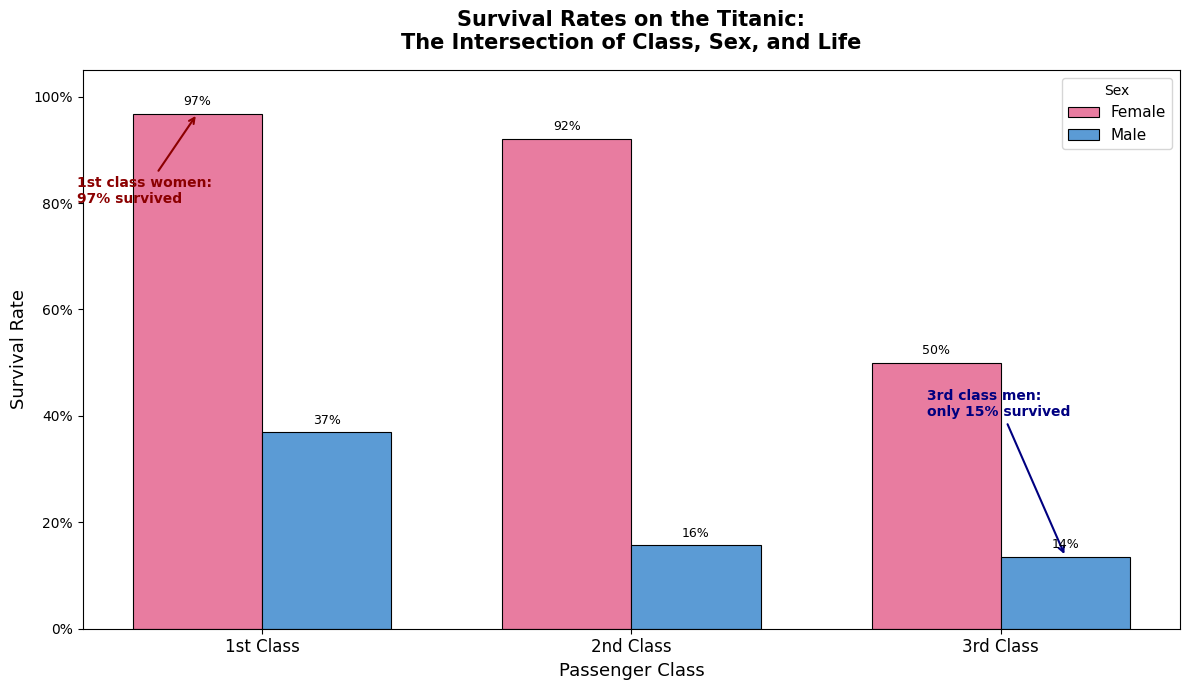

'\nDATA JOURNALISM CAPTION:\nThe Titanic disaster laid bare the brutal intersection of class privilege and gender-based\nevacuation policy. First-class women were saved at a near-perfect rate of 97%, while\nthird-class men perished at a rate exceeding 85%. The chart reveals a striking class\ngradient for male passengers — survival fell from 37% in first class to just 15% in\nthird class — suggesting that physical access to lifeboats (located on upper decks)\ncreated a lethal disadvantage for lower-deck passengers. Women across all classes\nfared better than men, confirming that the "women and children first" order was applied,\nyet even this policy was filtered through class: a third-class woman\'s chance of survival\n(~50%) was barely better than a first-class man\'s (~37%). What this chart cannot answer\nis whether the survival gap between classes reflects active discrimination, architectural\nbarriers, language barriers, or simply the chaos of an under-resourced evacuation —\nquesti

In [44]:
survival_multi = df.groupby(['pclass', 'sex'])['survived'].mean().unstack()
 
fig, ax = plt.subplots(figsize=(12, 7))
 
x = np.arange(3)
width = 0.35
 
bars_female = ax.bar(x - width/2, survival_multi['female'], width,
                     label='Female', color='#E87CA0', edgecolor='black', linewidth=0.8)
bars_male   = ax.bar(x + width/2, survival_multi['male'], width,
                     label='Male',   color='#5B9BD5', edgecolor='black', linewidth=0.8)
 
ax.set_title('Survival Rates on the Titanic:\nThe Intersection of Class, Sex, and Life',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Passenger Class', fontsize=13)
ax.set_ylabel('Survival Rate', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'], fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(title='Sex', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
 
# Annotation 1 — 1st class female survival
ax.annotate('1st class women:\n97% survived',
            xy=(-0.175, survival_multi.loc[1, 'female']),
            xytext=(-0.5, 0.80),
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
            fontsize=10, color='darkred', fontweight='bold')
 
# Annotation 2 — 3rd class male survival
ax.annotate('3rd class men:\nonly 15% survived',
            xy=(2 + 0.175, survival_multi.loc[3, 'male']),
            xytext=(1.8, 0.40),
            arrowprops=dict(arrowstyle='->', color='navy', lw=1.5),
            fontsize=10, color='navy', fontweight='bold')
 
# Value labels on bars
for bars in [bars_female, bars_male]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                f'{h:.0%}', ha='center', va='bottom', fontsize=9)
 
plt.tight_layout()
plt.show()
 
"""
DATA JOURNALISM CAPTION:
The Titanic disaster laid bare the brutal intersection of class privilege and gender-based
evacuation policy. First-class women were saved at a near-perfect rate of 97%, while
third-class men perished at a rate exceeding 85%. The chart reveals a striking class
gradient for male passengers — survival fell from 37% in first class to just 15% in
third class — suggesting that physical access to lifeboats (located on upper decks)
created a lethal disadvantage for lower-deck passengers. Women across all classes
fared better than men, confirming that the "women and children first" order was applied,
yet even this policy was filtered through class: a third-class woman's chance of survival
(~50%) was barely better than a first-class man's (~37%). What this chart cannot answer
is whether the survival gap between classes reflects active discrimination, architectural
barriers, language barriers, or simply the chaos of an under-resourced evacuation —
questions that historical accounts address but raw data alone cannot resolve.
"""